### Register and preprocess the final healthy ADC dataset
HCP-YA\
Dallas Lifespan Brain Study\
AINI-Stroke AIT

In [25]:
import os
import glob

import ants

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

import SimpleITK as sitk

from skimage.transform import resize

In [26]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [27]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [28]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    #print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


(197, 233, 189)


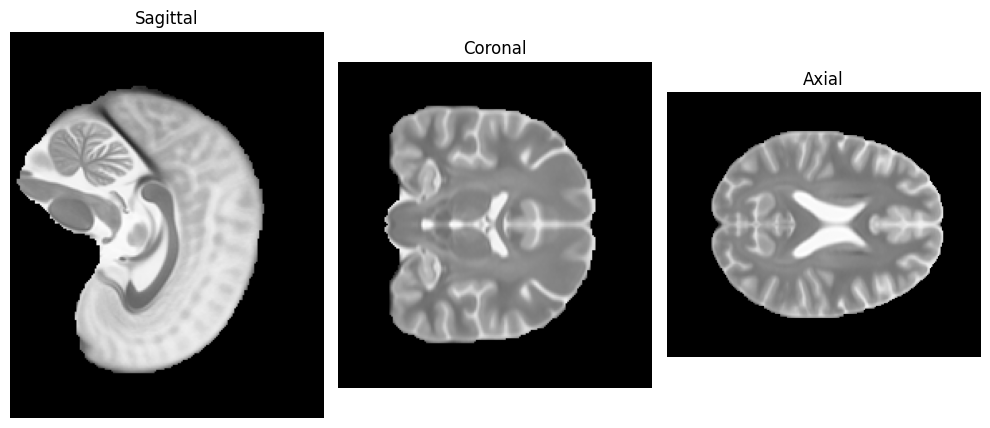

In [3]:
template_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/mni_icbm152_t2_tal_nlin_sym_09a_extracted_brain.nii.gz"
template_img = nib.load(template_path)
template_data = template_img.get_fdata()
print(template_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_data[template_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_data[:, template_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_data[:, :, template_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Pad and resize the template to (128,128,128)

In [4]:
original_shape = template_data.shape

# Calculate padding for each dimension
pad_width = []
for orig, target in zip(original_shape, (233, 233, 233)):
    total_pad = max(target - orig, 0)
    before = total_pad // 2
    after = total_pad - before
    pad_width.append((before, after))

# Pad the image
template_data = np.pad(template_data, pad_width, mode='constant', constant_values=0)

# Resize to (128, 128, 128)
template_data = resize(template_data, (128, 128, 128), anti_aliasing=True)

# Save the padded and resized image
padded_template_img = nib.Nifti1Image(template_data, template_img.affine, template_img.header)
output_template_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_FINAL_mni_icbm152_t2_tal_nlin_sym_09a_extracted_brain_padded_resized.nii.gz"
nib.save(padded_template_img, output_template_path)

Final template
(128, 128, 128)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

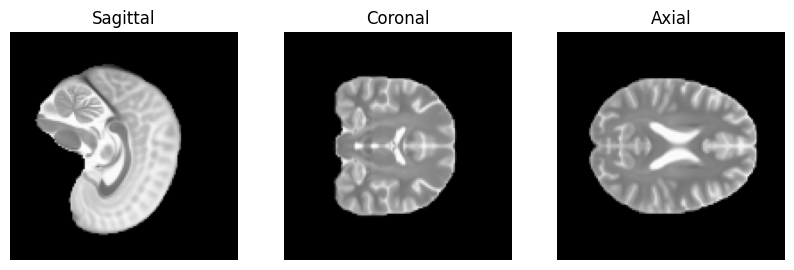

In [5]:
template_final = nib.load(output_template_path)
template_final_data = template_final.get_fdata()
print("Final template")
print(template_final_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_final_data[template_final_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_final_data[:, template_final_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_final_data[:, :, template_final_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")


## HCP-YA: 
Original Size: (174, 145, 145)\
1. pad it to (174,174,174)
2. Orient it like MNI
3. Resize it to (128, 128, 128)
4. Register it to histogram matched MNI

In [6]:
HCP_YA_folder = ROOT_DIR+"datasets/ADC_Human_Connectome_Project_Young_Adult_HCP-YA/"
HCP_YA_output_folder = ROOT_DIR+"datasets/final_adc_dataset_small/HCP-YA/"
HCP_YA_output_folder_registered = ROOT_DIR+"datasets/final_adc_dataset_small/HCP-YA_registered/"

#### Visualize unprocessed HCP-YA images

Image 1 shape: (174, 145, 145)
Image 2 shape: (174, 145, 145)
Image 3 shape: (174, 145, 145)
Image 4 shape: (174, 145, 145)


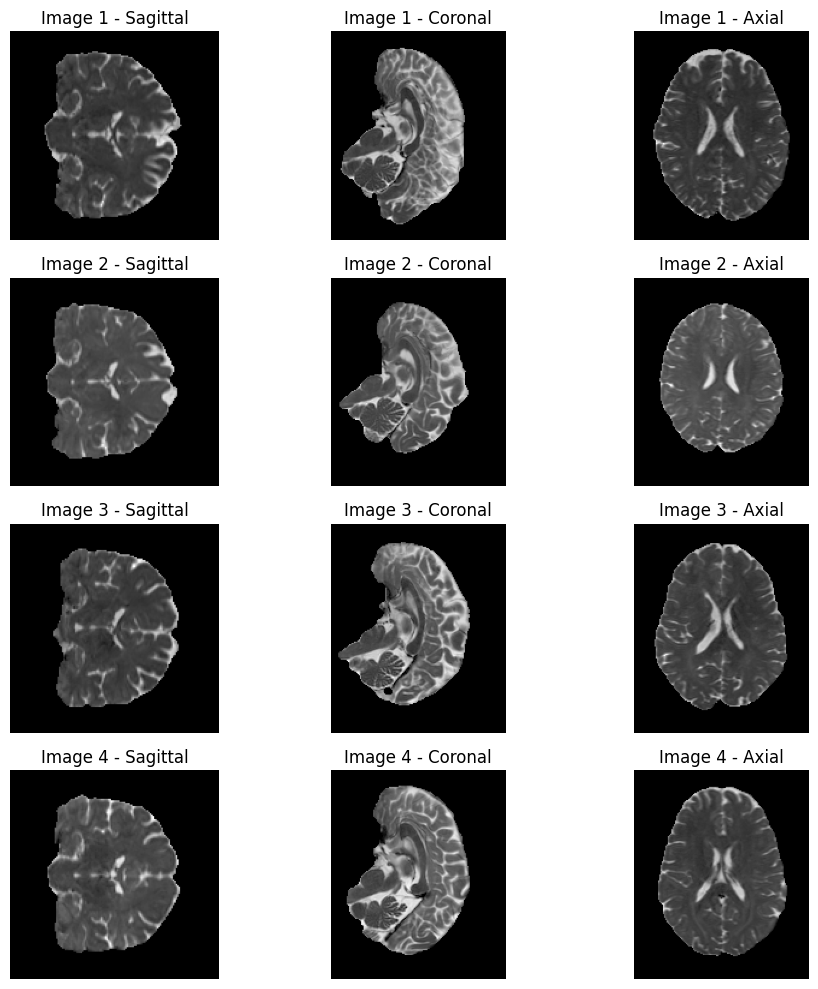

In [7]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(HCP_YA_folder, "*.nii.gz")))[:4]

# Plot the images
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

#### Procees HCP-YA images

In [8]:
def histogram_match_nifti(input_image_path, reference_image_path, output_image_path):
    """
    Performs histogram matching on a 3D NIfTI image based on a reference image.

    Parameters:
    - input_image_path: Path to the input NIfTI image to be matched.
    - reference_image_path: Path to the reference NIfTI image.
    - output_image_path: Path to save the histogram-matched NIfTI image.
    """
    # Load the input and reference images using SimpleITK
    input_image = sitk.ReadImage(input_image_path, sitk.sitkFloat32)
    reference_image = sitk.ReadImage(reference_image_path, sitk.sitkFloat32)

    # Perform histogram matching
    matcher = sitk.HistogramMatchingImageFilter()
    matcher.SetNumberOfHistogramLevels(256)
    matcher.SetNumberOfMatchPoints(15)
    matcher.SetThresholdAtMeanIntensity(True)

    matched_image = matcher.Execute(input_image, reference_image)

    # Save the matched image
    sitk.WriteImage(matched_image, output_image_path)

# histogram matching the template to the first hcp-ya image
histogram_match_nifti(input_image_path=output_template_path, 
                      reference_image_path=HCP_YA_folder+"104416.nii.gz", 
                      output_image_path=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz")

Final template
(128, 128, 128)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

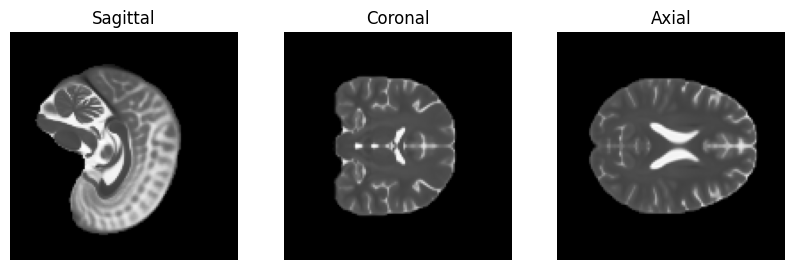

In [9]:
hist_match_template_final = nib.load(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz")
hist_match_template_final_data = hist_match_template_final.get_fdata()
print("Final template")
print(hist_match_template_final_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(hist_match_template_final_data[hist_match_template_final_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(hist_match_template_final_data[:, hist_match_template_final_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(hist_match_template_final_data[:, :, hist_match_template_final_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")


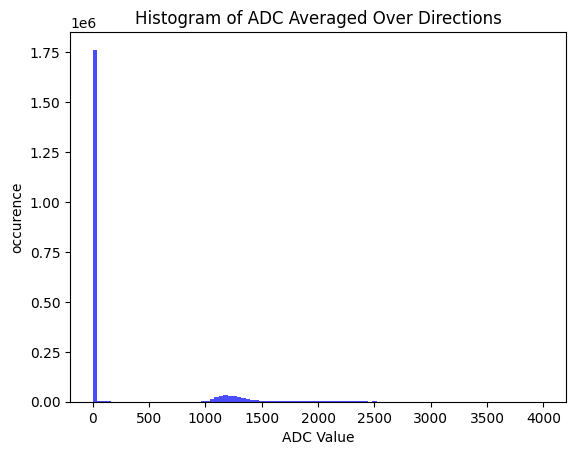

In [10]:
plt.hist(hist_match_template_final_data.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histogram of ADC Averaged Over Directions')
plt.xlabel('ADC Value')
plt.ylabel('occurence')
plt.show()

In [11]:
# Create output folder for padded images
os.makedirs(HCP_YA_output_folder, exist_ok=True)

nifti_files = sorted(glob.glob(os.path.join(HCP_YA_folder, "*.nii.gz")))

for file_path in tqdm(nifti_files):
    out_path = os.path.join(HCP_YA_output_folder, os.path.basename(file_path))
    if not os.path.exists(out_path):
        img = nib.load(file_path)
        data = img.get_fdata()
        
        original_shape = data.shape

        # Calculate padding for each dimension
        pad_width = []
        for orig, target in zip(original_shape, (174, 174, 174)):
            total_pad = max(target - orig, 0)
            before = total_pad // 2
            after = total_pad - before
            pad_width.append((before, after))

        # Pad the image
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

        # Rotate it 90 degrees
        data  = np.rot90(data, 3, axes=(0, 1)) 

        # Resize to (128, 128, 128)
        data = resize(data, (128, 128, 128), anti_aliasing=True)

        
        # Save padded image
        padded_img = nib.Nifti1Image(data, img.affine, img.header)
        
        nib.save(padded_img, out_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1015/1015 [07:12<00:00,  2.35it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


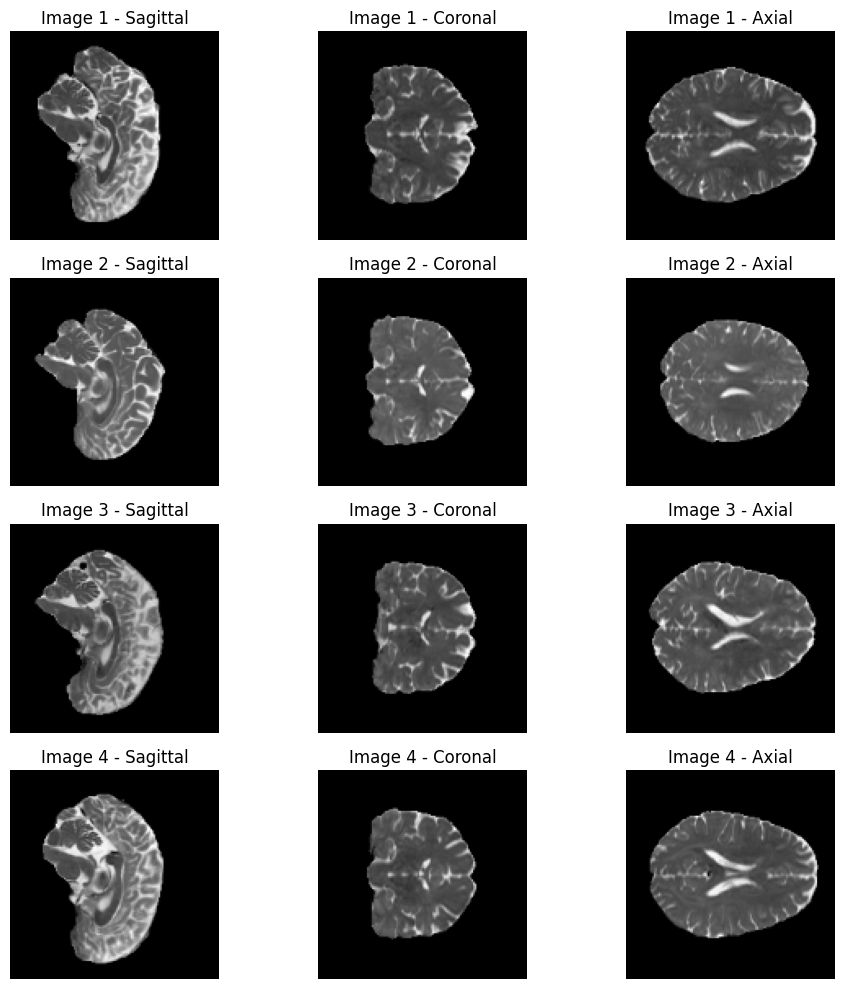

In [13]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(HCP_YA_output_folder, "*.nii.gz")))[:4]

# Plot the images
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [13]:


def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_mask_path=None, skip_already_done=True):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        #print(f"file {i} of {len(nifti_files)}")
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_mask_path, os.path.basename(mask_file))
        
        
        if os.path.isfile(output_filepath) and skip_already_done:
            continue
        else:
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
            #print("skipped registration already done")




In [15]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                     dataset_path=HCP_YA_output_folder, 
                     output_path=HCP_YA_output_folder_registered)

nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/100206.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/100307.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/100408.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/100610.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/101006.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/101107.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/101309.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/101410.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/101915.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/HCP-YA/102008.nii.gz', '/bettik/PROJECTS/pr-gin5_a

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1015/1015 [14:25<00:00,  1.17it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


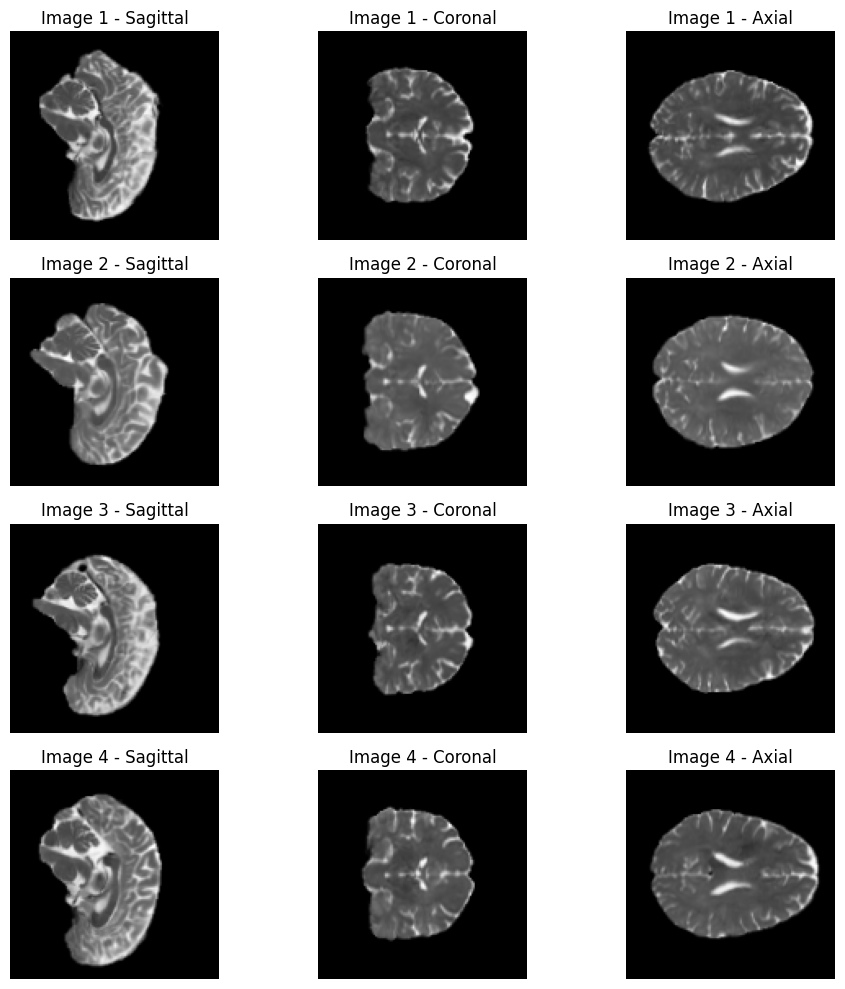

In [16]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(HCP_YA_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## Dallas Lifespan Brain Study
Original Size: (224, 224, 150)\
1. Resample it to 1mm3
2. pad it to (224, 224, 224)
3. Resize to (128, 128, 128)
4. Orient it like MNI
5. Register it to histogram matched MNI

In [24]:
dallas_adc_unprocessed_folder = ROOT_DIR+"datasets/Dallas_Computed_ADC_extracted_brain/"
dallas_resampled_output_folder = ROOT_DIR+"datasets/Dallas_Computed_ADC_extracted_brain_resampled/"
os.makedirs(dallas_resampled_output_folder, exist_ok=True)

dallas_final_output_folder = ROOT_DIR+"datasets/final_adc_dataset_small/Dallas/"
os.makedirs(dallas_final_output_folder, exist_ok=True)
dallas_final_output_folder_registered = ROOT_DIR+"datasets/final_adc_dataset_small/Dallas_registered/"
os.makedirs(dallas_final_output_folder_registered, exist_ok=True)

In [3]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [26]:
for image_path in tqdm(glob.glob(os.path.join(dallas_adc_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(dallas_resampled_output_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 955/955 [31:05<00:00,  1.95s/it]


Image 1 shape: (224, 224, 150)
Image 2 shape: (224, 224, 150)
Image 3 shape: (224, 224, 150)
Image 4 shape: (224, 224, 150)


<Figure size 640x480 with 0 Axes>

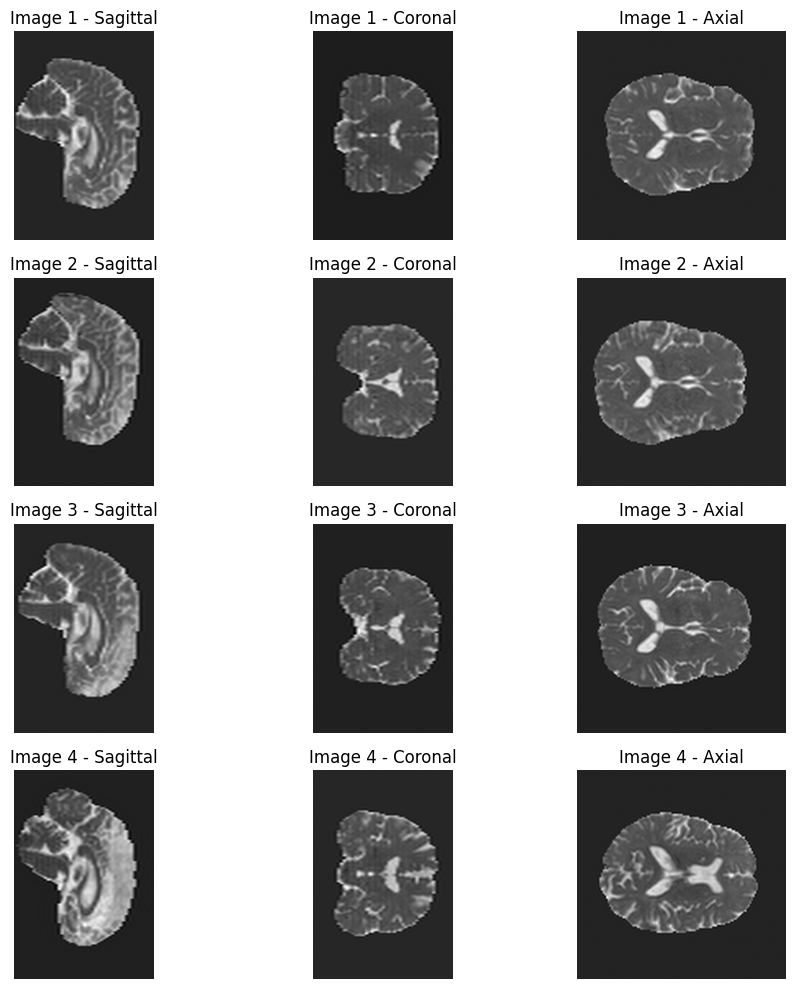

In [27]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_resampled_output_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [30]:
# pad to (224, 224, 224) and resize to (128, 128, 128)
os.makedirs(dallas_resampled_output_folder, exist_ok=True)

nifti_files = sorted(glob.glob(os.path.join(dallas_resampled_output_folder, "*.nii.gz")))
os.makedirs(dallas_final_output_folder, exist_ok=True)

for file_path in tqdm(nifti_files):
    out_path = os.path.join(dallas_final_output_folder, os.path.basename(file_path))
    if True: #not os.path.exists(out_path):
        img = nib.load(file_path)
        data = img.get_fdata()
        
        original_shape = data.shape

        # Calculate padding for each dimension
        pad_width = []
        for orig, target in zip(original_shape, (224, 224, 224)):
            total_pad = max(target - orig, 0)
            before = total_pad // 2
            after = total_pad - before
            pad_width.append((before, after))

        # Pad the image
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

        data = resize(data, (128, 128, 128), anti_aliasing=True)

        # Save padded image
        padded_img = nib.Nifti1Image(data, img.affine, img.header)
        
        nib.save(padded_img, out_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 955/955 [18:03<00:00,  1.13s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

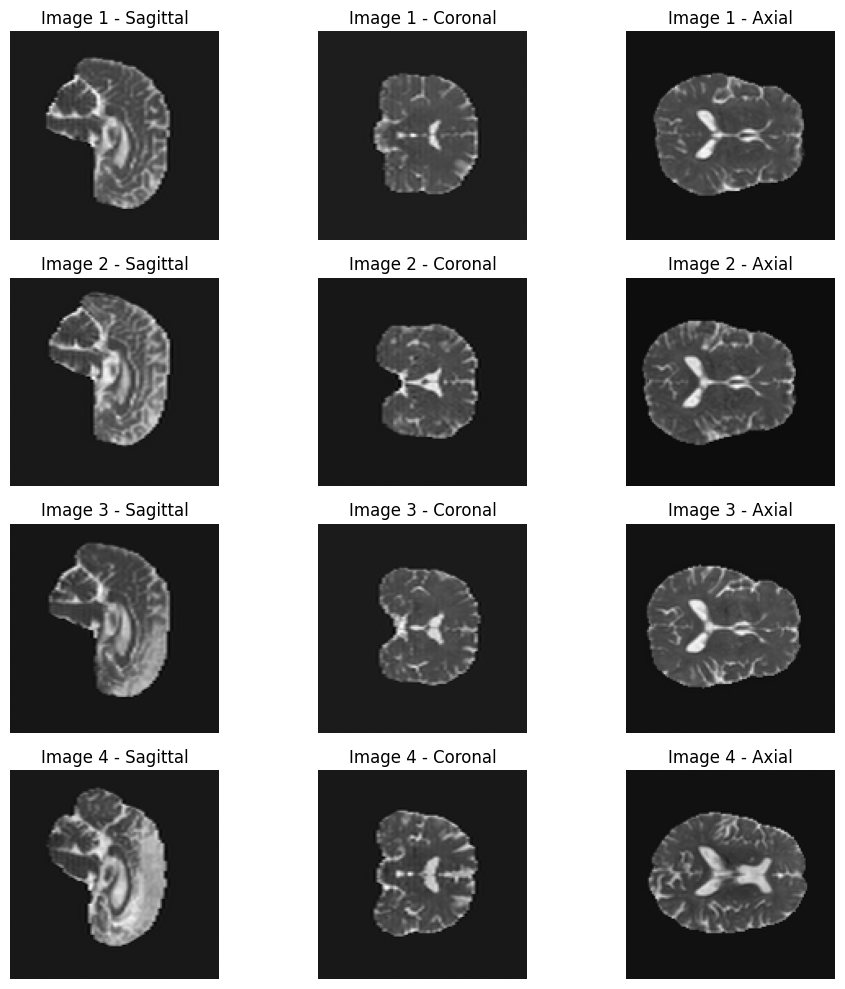

In [32]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_final_output_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [33]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                     dataset_path=dallas_final_output_folder, 
                     output_path=dallas_final_output_folder_registered)

nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1003_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1003_ses-wave2_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1003_ses-wave3_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1007_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1007_ses-wave2_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1007_ses-wave3_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1008_ses-wave1_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1008_ses-wave2_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_adc_dataset_small/Dallas/sub-1011_se

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 955/955 [18:23<00:00,  1.16s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

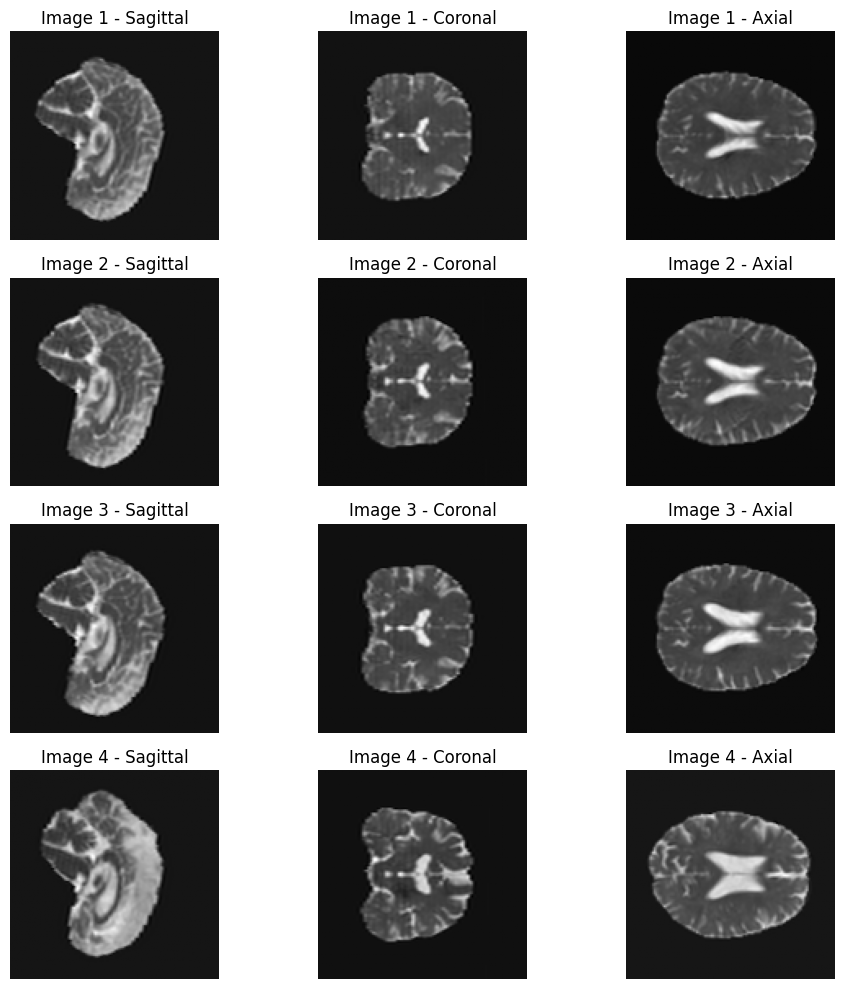

In [35]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## AINI-Stroke ADC
Original Size: (280, 280, 36)\
1. Resample it to 1mm3
Pad

1. Resize to (128, 128, 128)
2. Orient it like MNI
4. Register it to histogram matched MNI

In [3]:
AINI_stroke_ait_adc_unprocessed_folder = ROOT_DIR+"/datasets/Aini-Stroke_ADC/AIT_extracted_brain/"

AINI_stroke_ait_adc_resized_folder = ROOT_DIR+"/datasets/final_adc_dataset/AIT_extracted_brain_resampled/"

AINI_stroke_ait_adc_final_output_folder_registered = ROOT_DIR+"/datasets/final_adc_dataset/AIT_final_registered/"

Image 1 shape: (280, 280, 36)
Image 2 shape: (280, 280, 36)
Image 3 shape: (280, 280, 36)
Image 4 shape: (280, 280, 36)


<Figure size 640x480 with 0 Axes>

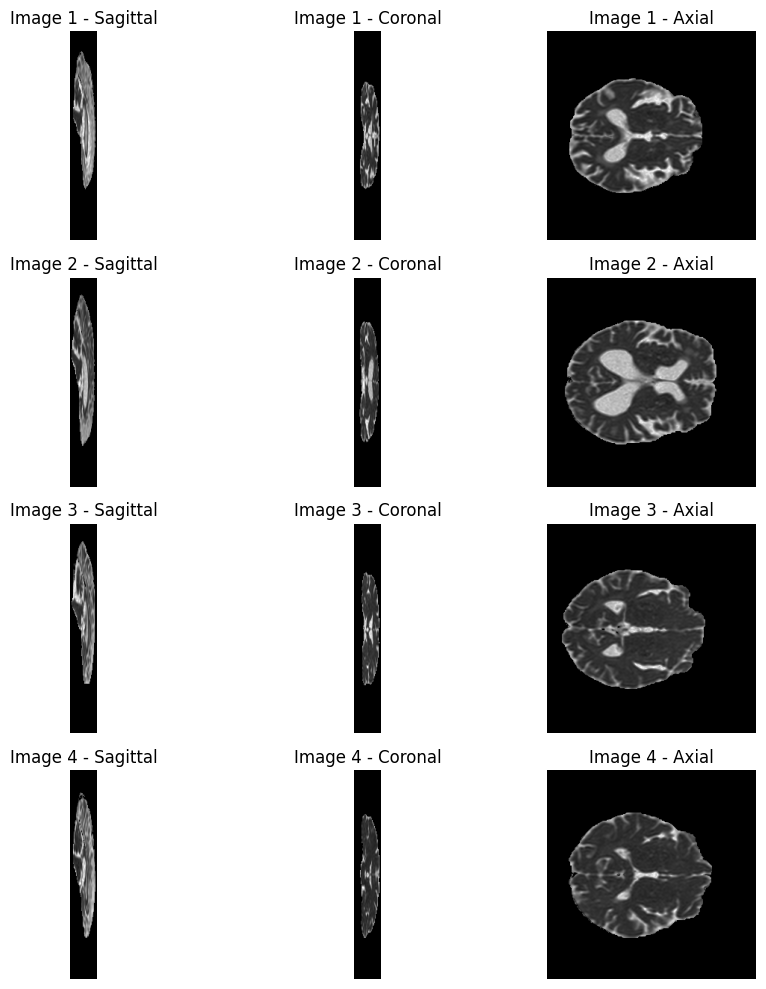

In [4]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(AINI_stroke_ait_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
os.makedirs(AINI_stroke_ait_adc_resized_folder, exist_ok=True)

for image_path in tqdm(glob.glob(os.path.join(AINI_stroke_ait_adc_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(AINI_stroke_ait_adc_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


  0%|                                                                                                                                              | 0/75 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:30<00:00,  2.46it/s]


Image 1 shape: (240, 240, 158)
Image 2 shape: (230, 230, 158)
Image 3 shape: (230, 230, 158)
Image 4 shape: (230, 230, 158)


<Figure size 640x480 with 0 Axes>

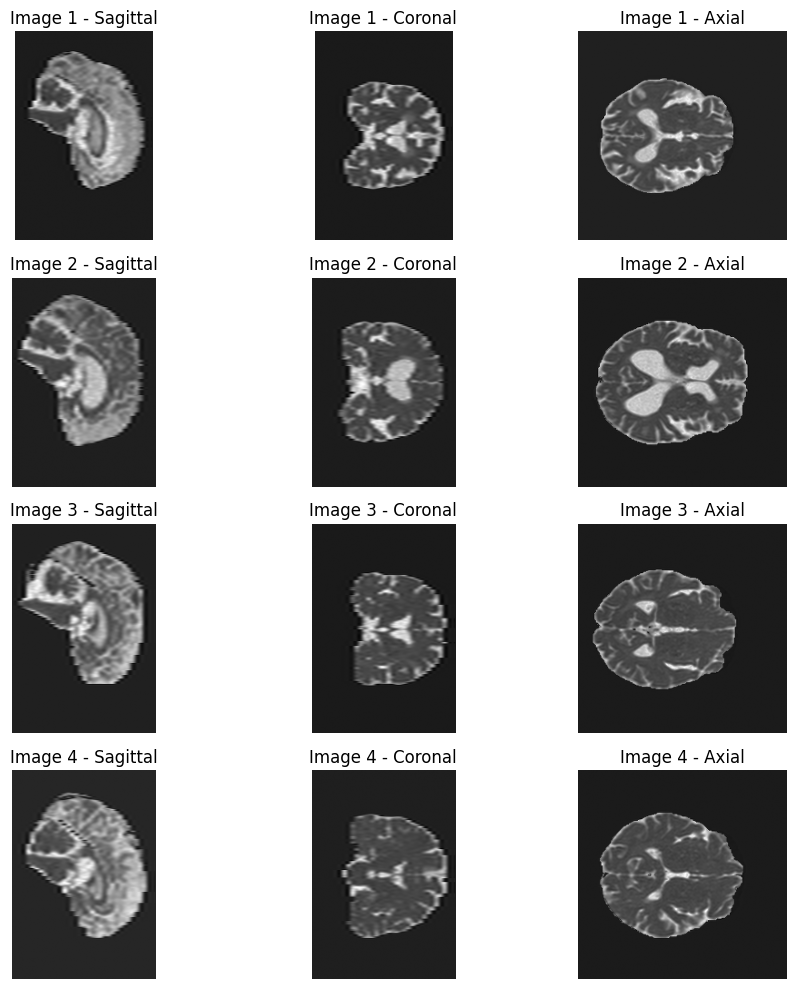

In [10]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(AINI_stroke_ait_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [11]:


for image_path in tqdm(glob.glob(os.path.join(AINI_stroke_ait_adc_resized_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (240, 240, 240)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    # Resize to (128, 128, 128)
    image_data = resize(image_data, (128, 128, 128), anti_aliasing=True)

    output_path = os.path.join(AINI_stroke_ait_adc_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:23<00:00,  3.13it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

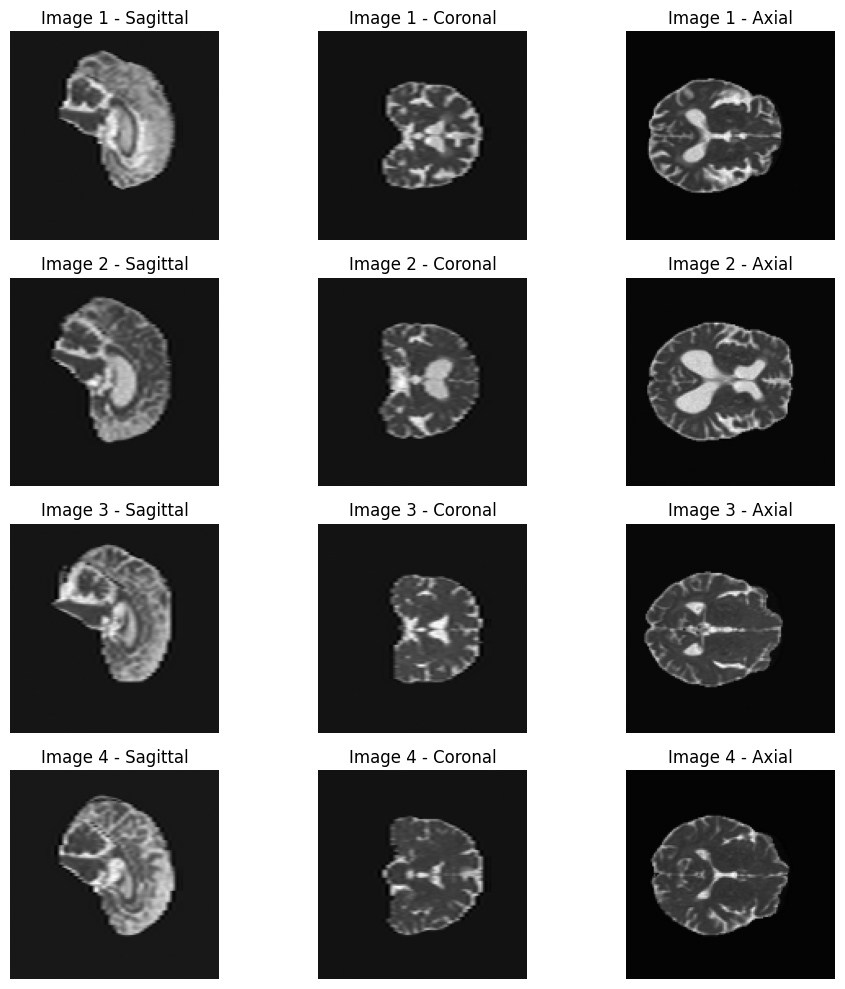

In [12]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(AINI_stroke_ait_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [15]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                     dataset_path=AINI_stroke_ait_adc_resized_folder, 
                     output_path=AINI_stroke_ait_adc_final_output_folder_registered)

nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-12040_423331_ADC_DIFF_EPI_3_NEX_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-12064_423375_ADC_DIFF_EPI_3_NEX_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-12399_423431_ADC_DIFF_EPI_3_NEX_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-12448_423443_ADC_DIFF_EPI_3_NEX_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-12484_423495_ADC_DIFF_TRA_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dataset/AIT_extracted_brain_resampled/aini-stroke-13105_423600_ADC_DIFF_EPI_3_NEX_ADC.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_adc_dat

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [01:02<00:00,  1.20it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

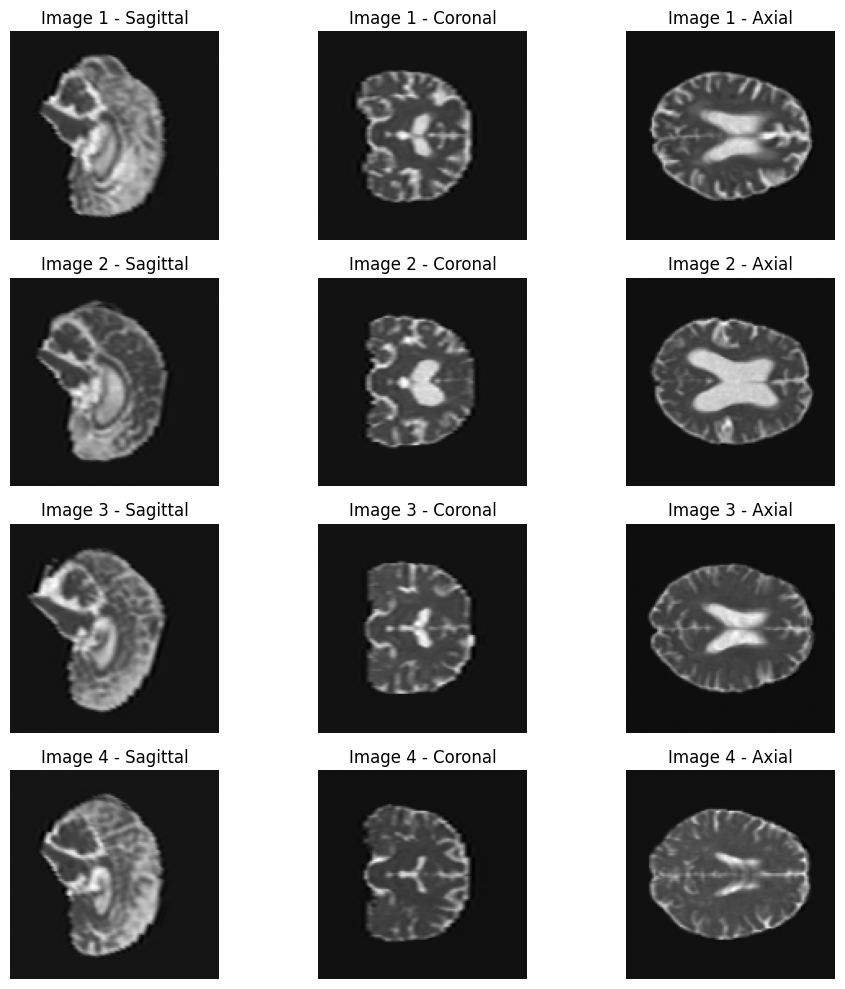

In [16]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(AINI_stroke_ait_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## IXI_ADC: 
Original Size: (128, 128, 56)\
1. resample to 1mm3
2. pad it to (128,128,128)
3. Register it to histogram matched MNI

In [5]:
ixi_adc_unprocessed_folder = ROOT_DIR+"datasets/ixi_adc_skullstrip/"
ixi_adc_resized_folder = ROOT_DIR+"datasets/ixi_adc_resized/"
os.makedirs(ixi_adc_resized_folder, exist_ok=True)

ixi_adc_final_output_folder_registered = ROOT_DIR+"datasets/final_adc_dataset_small/ixi_registered/"
os.makedirs(ixi_adc_final_output_folder_registered, exist_ok=True)

Image 1 shape: (128, 128, 56)
Image 2 shape: (128, 128, 56)
Image 3 shape: (128, 128, 56)
Image 4 shape: (128, 128, 56)


<Figure size 640x480 with 0 Axes>

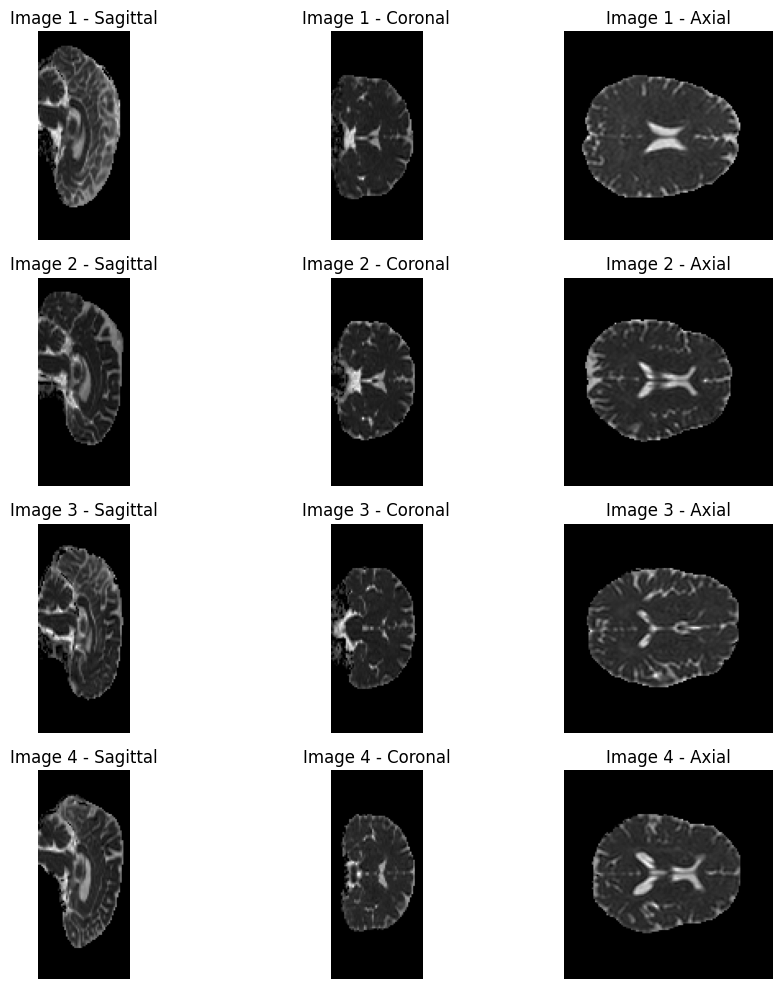

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# resample to 1mm3

for image_path in tqdm(glob.glob(os.path.join(ixi_adc_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(ixi_adc_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [07:11<00:00,  1.09s/it]


Image 1 shape: (224, 224, 132)
Image 2 shape: (224, 224, 132)
Image 3 shape: (224, 224, 132)
Image 4 shape: (224, 224, 132)


<Figure size 640x480 with 0 Axes>

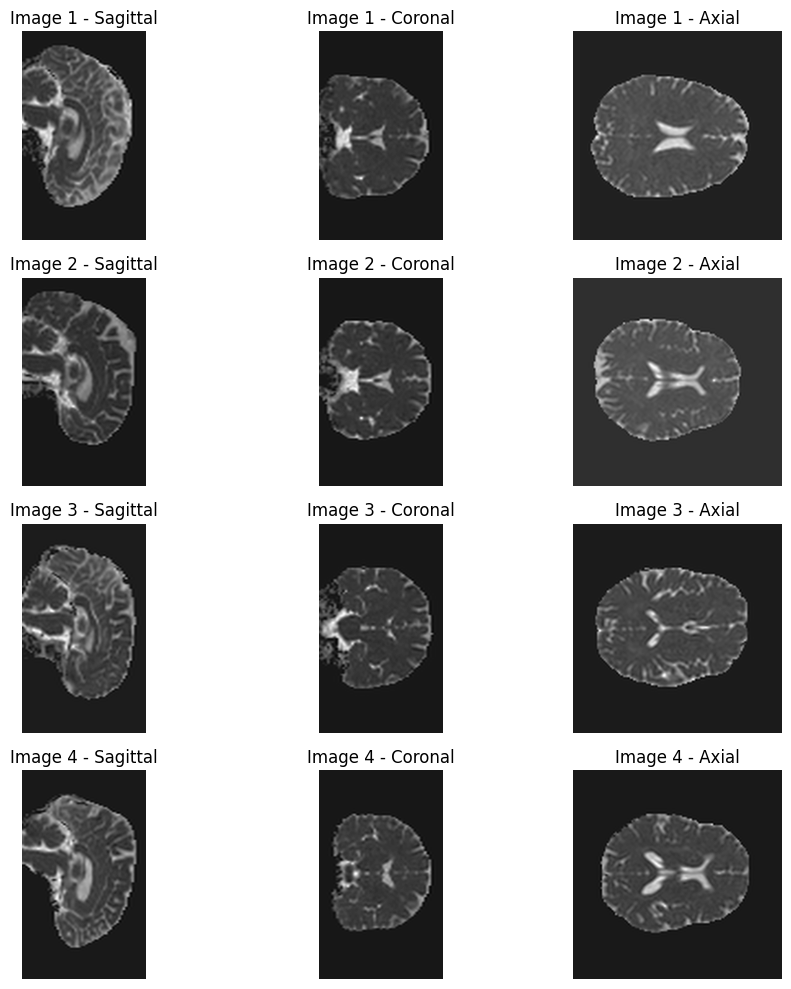

In [20]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    image[:, :, image.shape[2]-3:]=0
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
for image_path in tqdm(glob.glob(os.path.join(ixi_adc_resized_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)
    image_data[:, :, image_data.shape[2]-3:]=0
    
    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (224, 224, 224)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    # Resize to (128, 128, 128)
    image_data = resize(image_data, (160, 160, 160), anti_aliasing=True)

    output_path = os.path.join(ixi_adc_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [06:57<00:00,  1.06s/it]


Image 1 shape: (160, 160, 160)
Image 2 shape: (160, 160, 160)
Image 3 shape: (160, 160, 160)
Image 4 shape: (160, 160, 160)


<Figure size 640x480 with 0 Axes>

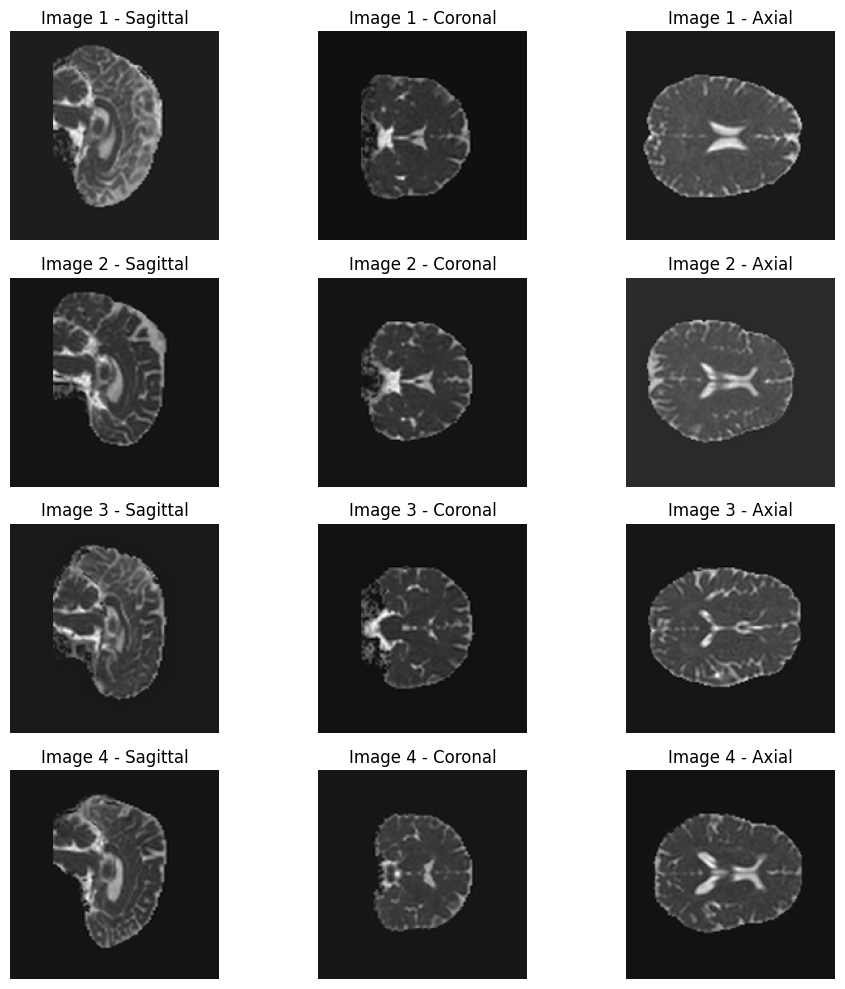

In [22]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [23]:
# images and masks
register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
                    dataset_path=ixi_adc_resized_folder, 
                    output_path=ixi_adc_final_output_folder_registered,
                    register_masks=False,
                    skip_already_done=False
                    )


nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0808_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0809_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0810_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0811_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0812_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0815_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0816_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0817_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0818_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0819_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0821_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ixi_adc_resized/0822_adc.

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [09:53<00:00,  1.50s/it]


12.23334789276123 -0.8832133412361145
Image 1 shape: (128, 128, 128)
5.220690727233887 -0.4132290482521057
Image 2 shape: (128, 128, 128)
4.86857271194458 -0.4941931962966919
Image 3 shape: (128, 128, 128)
4.8761138916015625 -0.3590661287307739
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

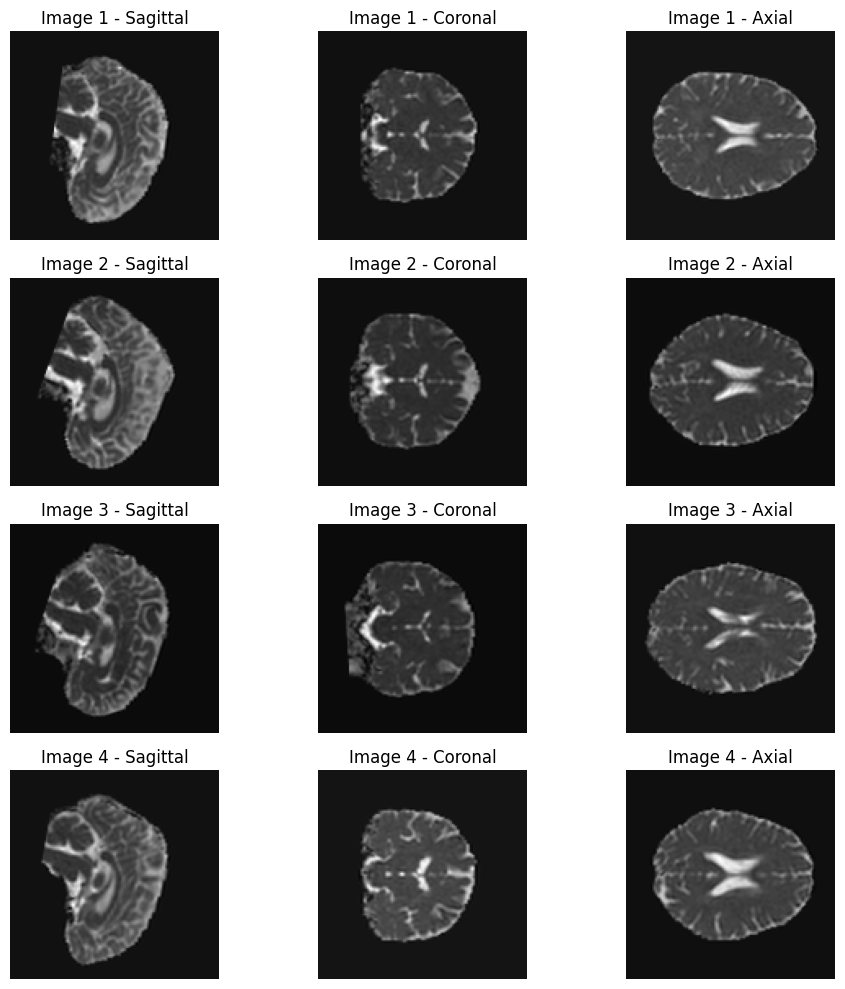

In [29]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(np.max(image), np.min(image))
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [32]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_final_output_folder_registered, "*.nii.gz")))

# Plot the images

for image_path in tqdm(image_paths):
    image = nib.load(image_path).get_fdata()
    
    image = np.clip(image, 0, 6000)
    
    nib.save(nib.Nifti1Image(image, np.eye(4)), image_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [02:21<00:00,  2.79it/s]


6000.0 0.0
Image 1 shape: (128, 128, 128)
5220.690727233887 0.0
Image 2 shape: (128, 128, 128)
4868.57271194458 0.0
Image 3 shape: (128, 128, 128)
4876.1138916015625 0.0
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

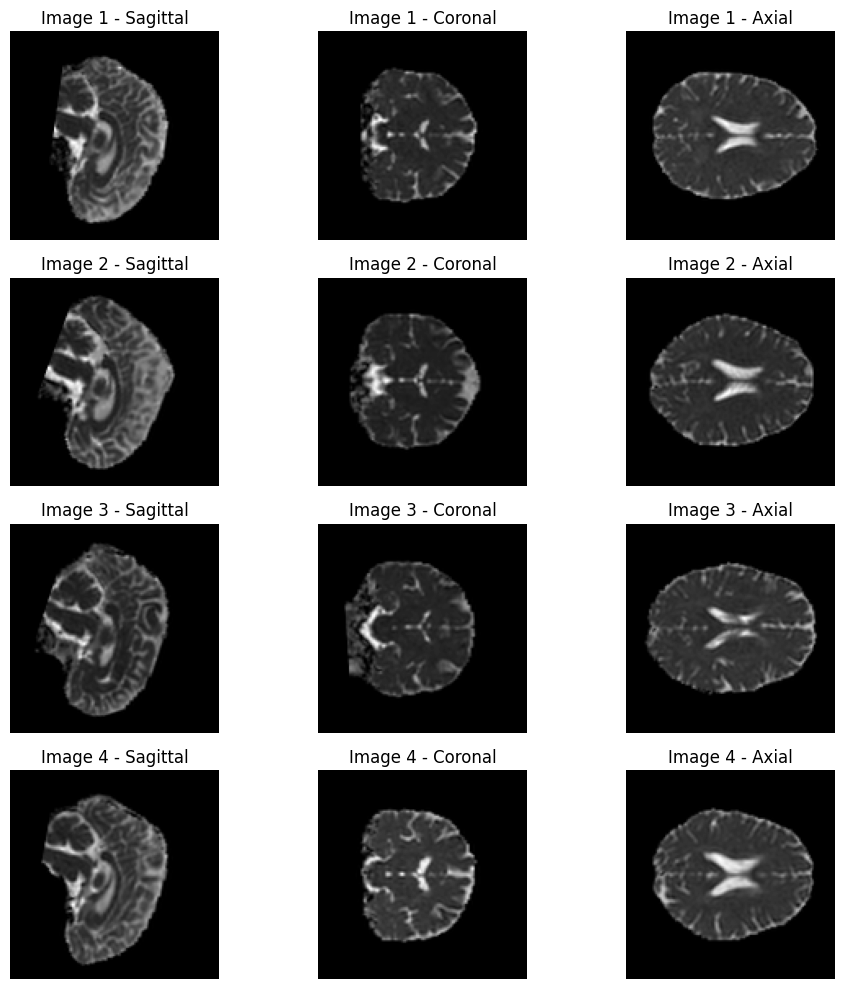

In [33]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ixi_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(np.max(image), np.min(image))
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## ISLES-2022 ADC
Original Size: (112, 112, 72)\
1. no resampling since they already have isotropic resolution (2, 2, 2)
2. PAD to (128, 128, 128)
4. Register it to histogram matched MNI

In [15]:
ISLES_adc_unprocessed_folder = ROOT_DIR+"/datasets/ISLES_ADC/"
ISLES_masks_unprocessed_folder = ROOT_DIR+"/datasets/ISLES_masks/"

ISLES_adc_resized_folder = ROOT_DIR+"/datasets/ISLES_ADC_resized/"
ISLES_masks_resized_folder = ROOT_DIR+"/datasets/ISLES_masks_resized/"

ISLES_adc_final_output_folder_registered = ROOT_DIR+"/datasets/final_adc_dataset_small/ISLES_registered/"
ISLES_masks_final_output_folder_registered = ROOT_DIR+"/datasets/final_adc_dataset_small/ISLES_masks_registered/"

Image 1 shape: (112, 112, 73)
Image 2 shape: (112, 112, 72)
Image 3 shape: (112, 112, 72)
Image 4 shape: (112, 112, 72)


<Figure size 640x480 with 0 Axes>

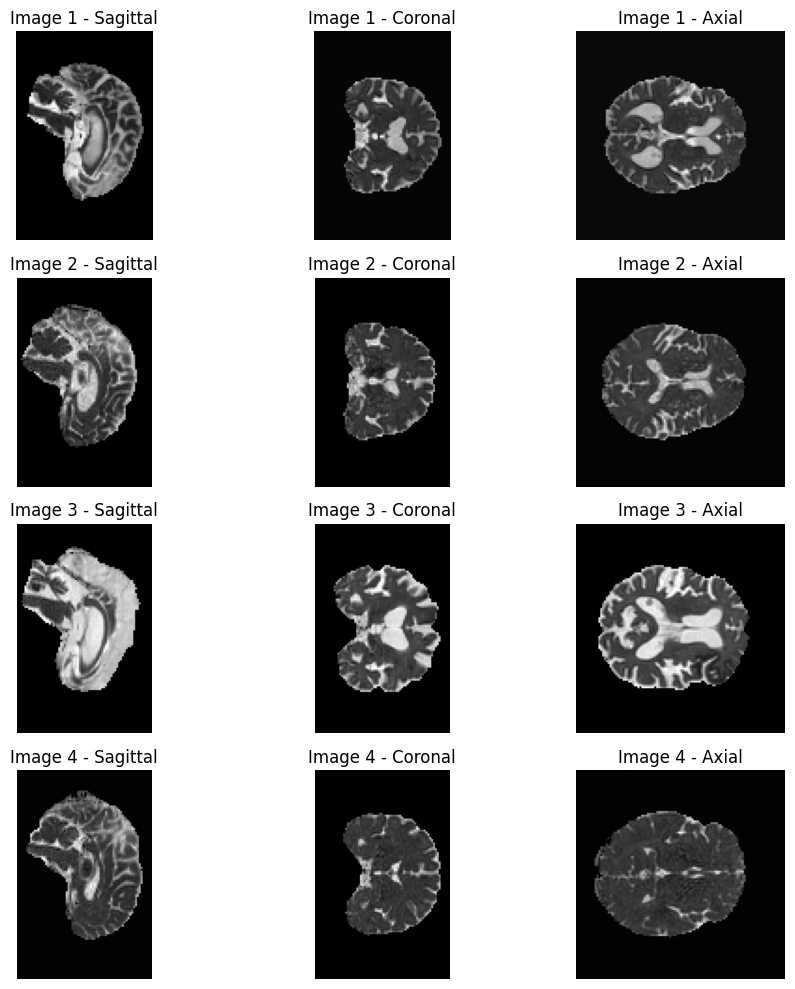

In [4]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ISLES_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
""" os.makedirs(ISLES_adc_resized_folder, exist_ok=True)

for image_path in tqdm(glob.glob(os.path.join(ISLES_adc_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(ISLES_adc_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)
 """

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [06:52<00:00,  1.65s/it]


In [16]:
# images
for image_path in tqdm(glob.glob(os.path.join(ISLES_adc_unprocessed_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (128, 128, 128)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(ISLES_adc_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)

# masks
for image_path in tqdm(glob.glob(os.path.join(ISLES_masks_unprocessed_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (128, 128, 128)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(ISLES_masks_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:12<00:00, 19.60it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

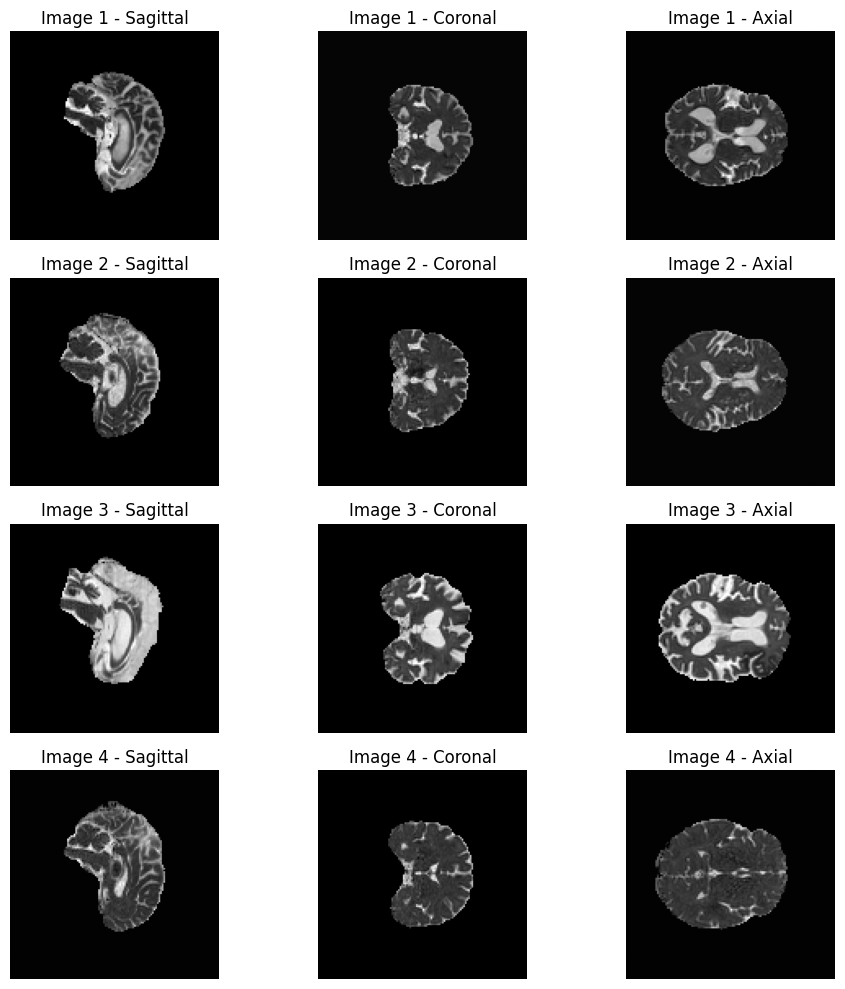

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ISLES_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(nifti_files):
        print(f"file {i} of {len(nifti_files)}")
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


In [22]:
# images and masks
register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                    dataset_path=ISLES_adc_resized_folder, 
                    output_path=ISLES_adc_final_output_folder_registered,
                    register_masks=True,
                    dataset_masks_path=ISLES_masks_resized_folder,
                    output_masks_path=ISLES_masks_final_output_folder_registered
                    )


nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0001_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0002_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0003_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0004_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0005_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0006_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0007_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0008_ses-0001_adc.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/ISLES_ADC_resized/sub-strokecase0009_ses-0001_adc.nii.gz', '/bett

Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)
Image 5 shape: (128, 128, 128)
Image 6 shape: (128, 128, 128)
Image 7 shape: (128, 128, 128)
Image 8 shape: (128, 128, 128)
Image 9 shape: (128, 128, 128)
Image 10 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

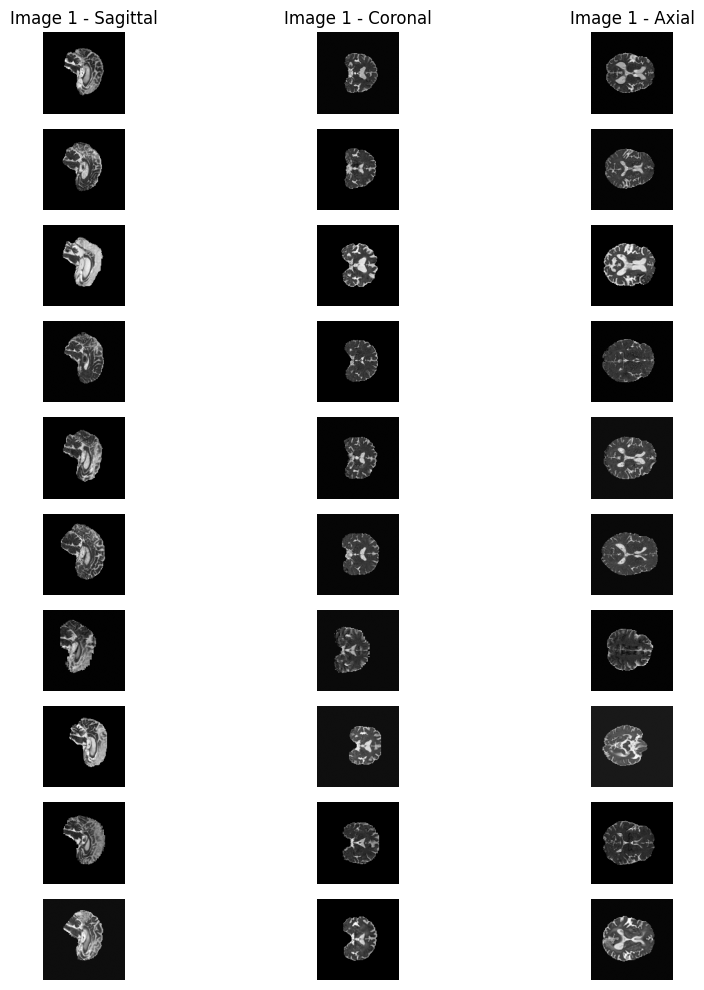

In [23]:
# Get the first 10 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ISLES_adc_resized_folder, "*.nii.gz")))[:10]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(10, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].axis("off")

    if i==0:
        axes[i, 0].set_title(f"Image {i+1} - Sagittal")
        axes[i, 1].set_title(f"Image {i+1} - Coronal")
        axes[i, 2].set_title(f"Image {i+1} - Axial")

plt.tight_layout()
plt.show()

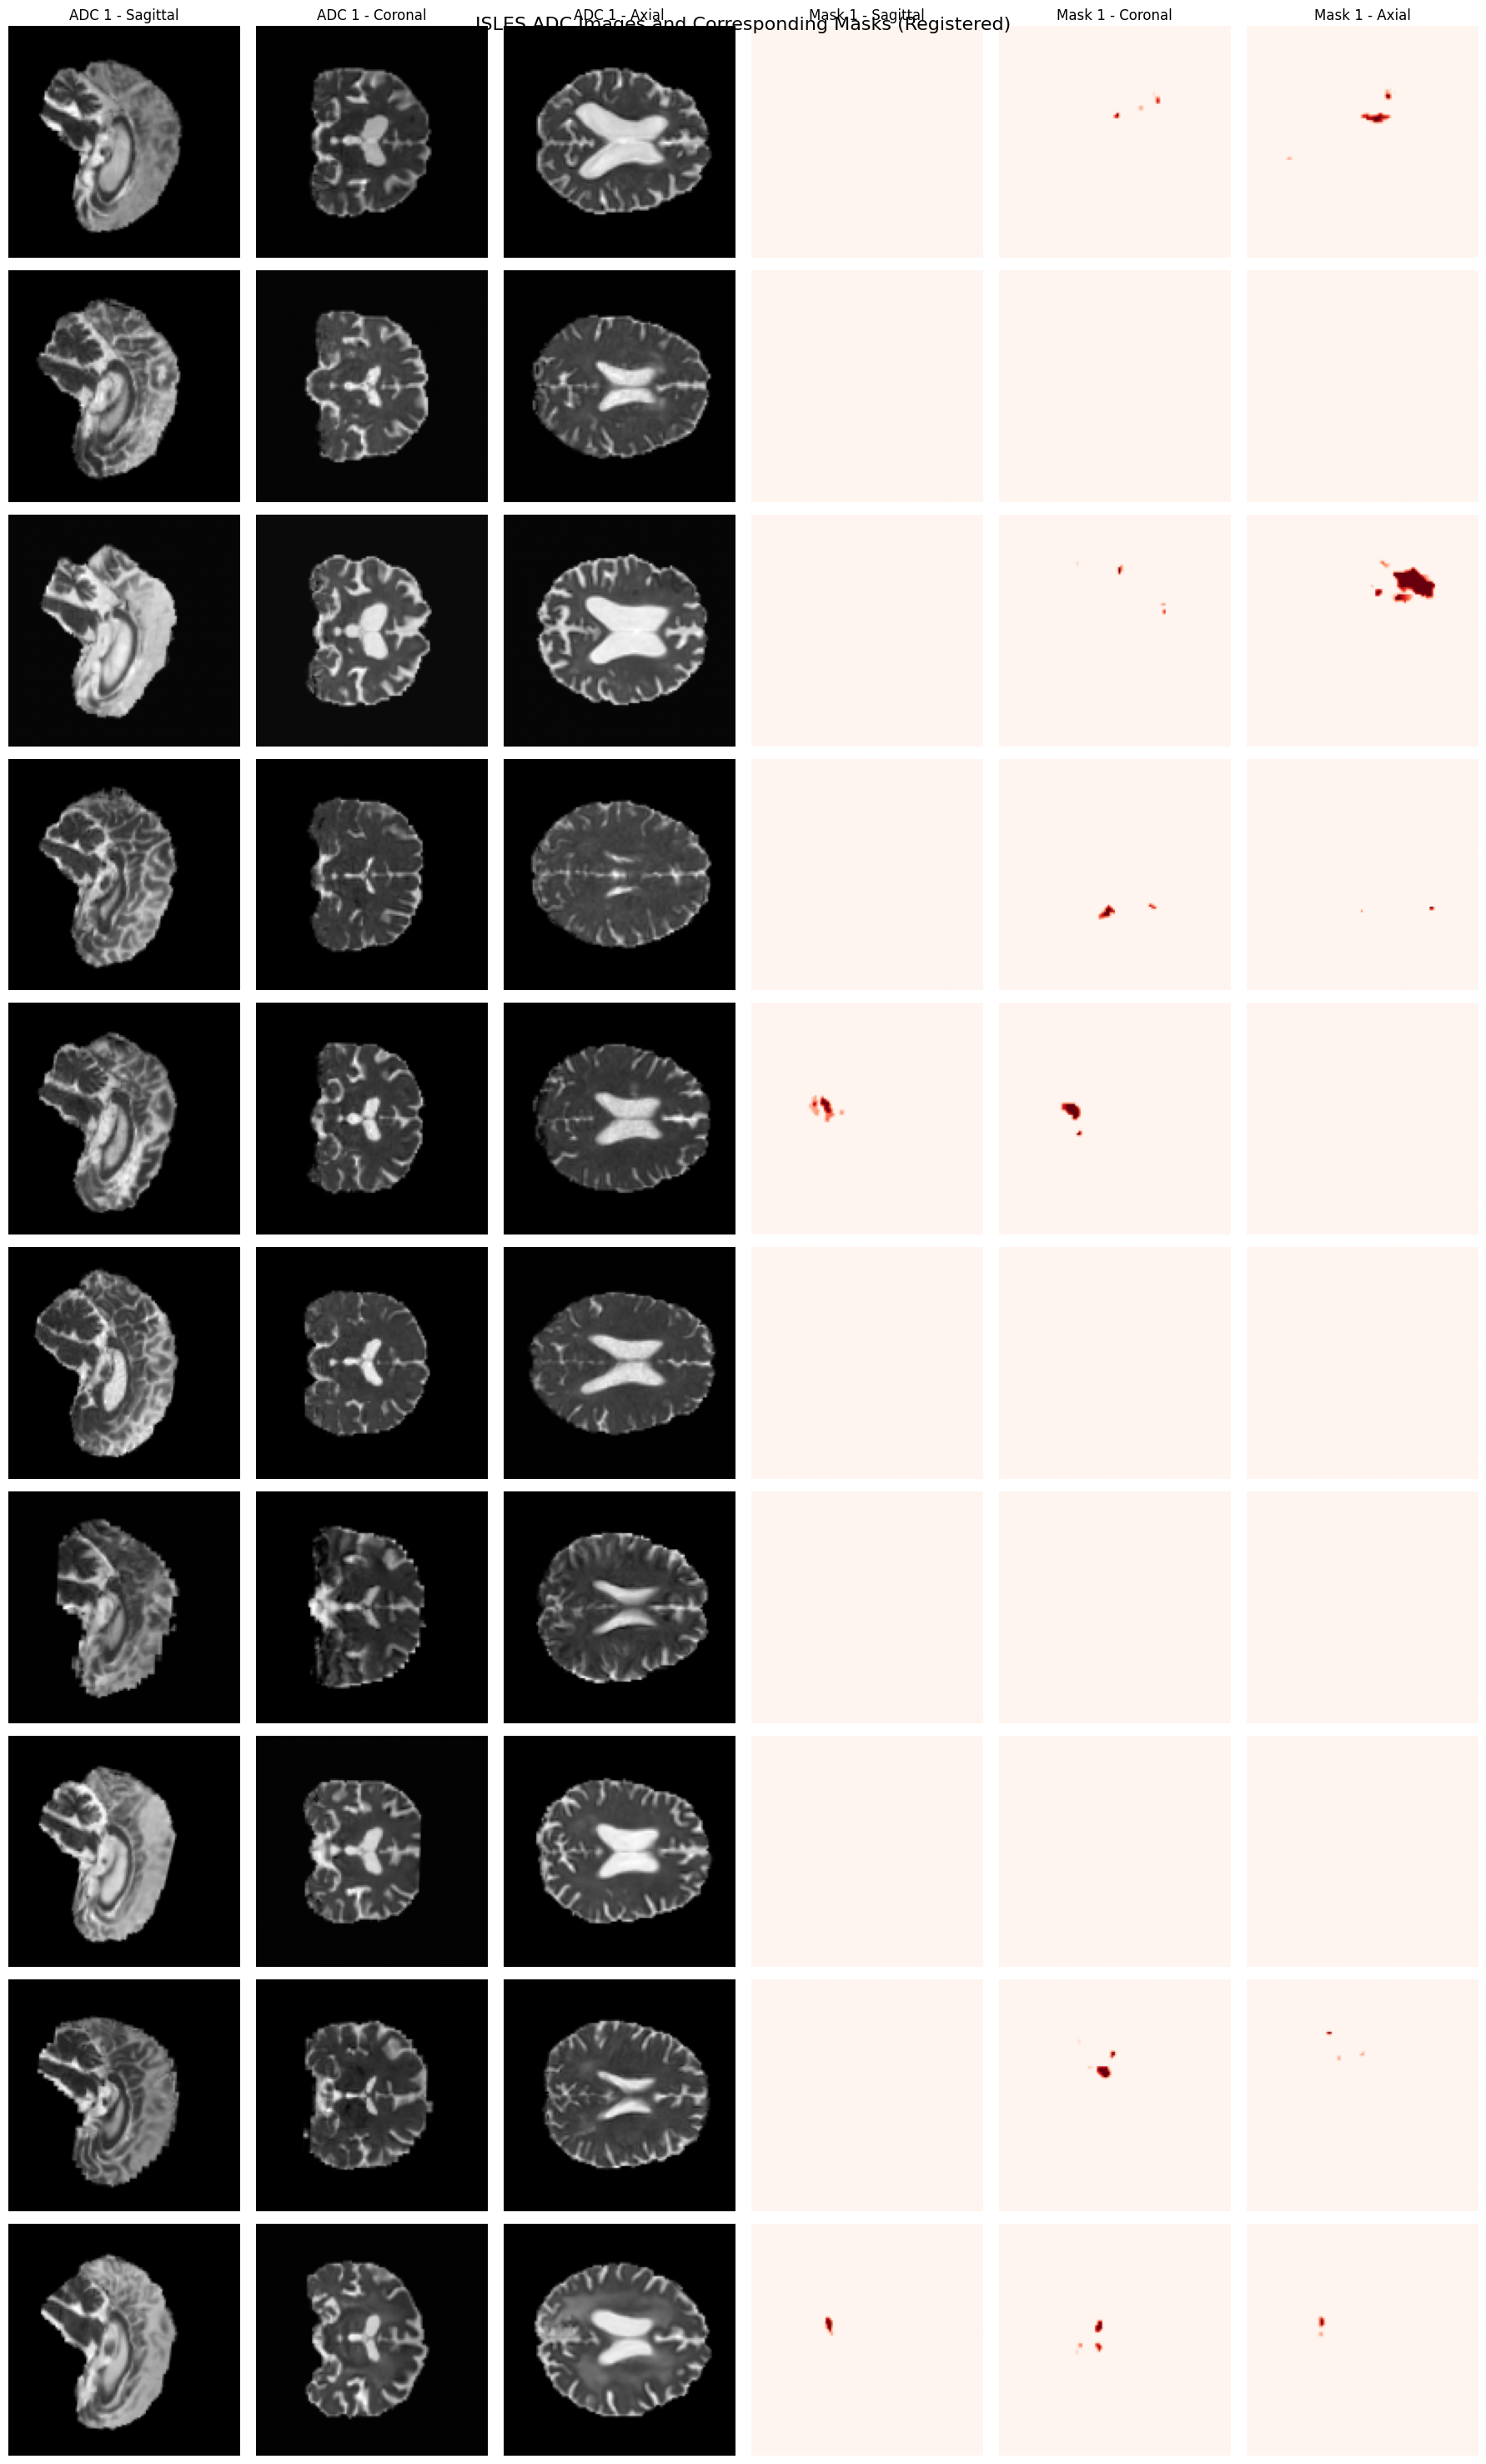

In [24]:
# Get sorted file paths for both ADC images and masks
adc_paths = sorted(glob.glob(os.path.join(ISLES_adc_final_output_folder_registered, "*.nii.gz")))
mask_paths = sorted(glob.glob(os.path.join(ISLES_masks_final_output_folder_registered, "*.nii.gz")))

# Take first 10 pairs for visualization
num_pairs = min(10, len(adc_paths), len(mask_paths))

fig, axes = plt.subplots(num_pairs, 6, figsize=(18, 3*num_pairs))
plt.suptitle("ISLES ADC Images and Corresponding Masks (Registered)", fontsize=16)

for i in range(num_pairs):
    # Load ADC image and mask
    adc_img = nib.load(adc_paths[i]).get_fdata()
    mask_img = nib.load(mask_paths[i]).get_fdata()
    
    # Get middle slices
    mid_slice = adc_img.shape[2] // 2
    adc_axial = adc_img[:, :, mid_slice]
    mask_axial = mask_img[:, :, mid_slice]
    
    mid_slice_sag = adc_img.shape[0] // 2
    adc_sagittal = adc_img[mid_slice_sag, :, :]
    mask_sagittal = mask_img[mid_slice_sag, :, :]
    
    mid_slice_cor = adc_img.shape[1] // 2
    adc_coronal = adc_img[:, mid_slice_cor, :]
    mask_coronal = mask_img[:, mid_slice_cor, :]
    
    # Plot ADC sagittal
    axes[i, 0].imshow(adc_sagittal, cmap="gray")
    axes[i, 0].set_title(f"ADC {i+1} - Sagittal" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Plot ADC coronal
    axes[i, 1].imshow(adc_coronal, cmap="gray")
    axes[i, 1].set_title(f"ADC {i+1} - Coronal" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Plot ADC axial
    axes[i, 2].imshow(adc_axial, cmap="gray")
    axes[i, 2].set_title(f"ADC {i+1} - Axial" if i == 0 else "")
    axes[i, 2].axis("off")
    
    # Plot Mask sagittal
    axes[i, 3].imshow(mask_sagittal, cmap="Reds")
    axes[i, 3].set_title(f"Mask {i+1} - Sagittal" if i == 0 else "")
    axes[i, 3].axis("off")
    
    # Plot Mask coronal
    axes[i, 4].imshow(mask_coronal, cmap="Reds")
    axes[i, 4].set_title(f"Mask {i+1} - Coronal" if i == 0 else "")
    axes[i, 4].axis("off")
    
    # Plot Mask axial
    axes[i, 5].imshow(mask_axial, cmap="Reds")
    axes[i, 5].set_title(f"Mask {i+1} - Axial" if i == 0 else "")
    axes[i, 5].axis("off")

plt.tight_layout()
plt.show()